In [77]:
#Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


np.random.seed(42)
tf.random.set_seed(42)

In [39]:
#Upload Dataset ke Drive
from google.colab import drive
drive.mount('/content/drive')

#Baca Dataset dari Google Drive
filename = '/content/drive/MyDrive/TUGAS_BESAR_ANN/Dry_Bean_Dataset.xlsx' # Define filename here

if filename.endswith(".csv"):
    data = pd.read_csv(filename)

elif filename.endswith(".xlsx"):
    data = pd.read_excel(filename)

else:
    raise Exception("Format file tidak didukung")

#Cek Dataset
print(data.shape)
print(data.info())
print(data.isnull().sum())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(13611, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFact

In [40]:
#Exploratory Data Analysis (EDA) //menampilkan karakteristik data yang digunakan
print("="*60)

print("Jumlah Data")
print(data.shape)

print("="*60)

print("Informasi Dataset")
print(data.info())

print("="*60)

print("5 Data Pertama")
display(data.head())

print("="*60)

print("Missing Value")

display(data.isnull().sum())

print("="*60)

print("Distribusi Class")

display(data.iloc[:,-1].value_counts())

print("="*60)

display(data.describe())

Jumlah Data
(13611, 17)
Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class           

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


Missing Value


,0
Area,0
Perimeter,0
MajorAxisLength,0
MinorAxisLength,0
AspectRation,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Solidity,0


Distribusi Class


,count
Class,
DERMASON,3546
SIRA,2636
SEKER,2027
HOROZ,1928
CALI,1630
BARBUNYA,1322
BOMBAY,522


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [41]:
#Memisahkan Fitur dan Label
X = data.iloc[:, :-1].copy()

y = data.iloc[:, -1].copy()

print("Feature")

display(X.head())

print()

print("Label")

display(y.head())

print()

print("Shape Feature :", X.shape)
print("Shape Label :", y.shape)

Feature


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166



Label


,Class
0,SEKER
1,SEKER
2,SEKER
3,SEKER
4,SEKER



Shape Feature : (13611, 16)
Shape Label : (13611,)


In [42]:
# One Hot Encoding //Karena data multiclass dan komputer hanya bisa membaca angka, maka harus diubah ke numerik
y = pd.get_dummies(y).astype(float).to_numpy()

print(type(y))
print(y.shape)
print(y[:5])

<class 'numpy.ndarray'>
(13611, 7)
[[0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0.]]


In [43]:
#Train split tes
X_train,X_test,y_train,y_test= train_test_split(  # X_train = latihan model / X_test = pengujian model // Y_train = Label yang jadi model / Y_test = Label yang di uji
X.to_numpy(),
y,
test_size=0.2, #Merubah jumlah data disini
random_state=42, #Mengunci pengacakan data agar bisa reproducible
shuffle=True
)


#Melihat hasil pembagian
print("Training :",X_train.shape)
print("Testing :",X_test.shape)
print("Training :",y_train.shape)
print("Testing :",y_test.shape)

Training : (10888, 16)
Testing : (2723, 16)
Training : (10888, 7)
Testing : (2723, 7)


In [44]:
#Standarisasi
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Standardisasi selesai")

print()

print(X_train[:3])

Standardisasi selesai

[[-0.82004684 -1.02202571 -0.9916898  -0.98658662 -0.38683443 -0.11414642
  -0.81795169 -1.02608142 -1.14259819 -0.25529323  0.48573853  0.30083254
   1.34481435  0.87409641  0.26508427  0.34316281]
 [-0.50936012 -0.46410379 -0.56941112 -0.49927378 -0.30311695 -0.02443629
  -0.50478713 -0.55276784 -0.88143121 -0.7076025  -0.57257341  0.20123818
   0.48567249  0.32551494  0.16383972  0.04702778]
 [-0.7548078  -0.95078365 -1.04911073 -0.67543815 -0.99009895 -0.93391355
  -0.75590261 -0.92118933 -0.3226722   0.36688224  0.72939953  1.01814277
   0.76574882  1.38029879  1.01678554  0.34322861]]


In [45]:
# Konfigurasi Model //ubah size semua disini

INPUT_SIZE = X_train.shape[1]

OUTPUT_SIZE = y_train.shape[1]

HIDDEN_SIZE = 64

LEARNING_RATE = 0.01

EPOCHS = 100

BATCH_SIZE = 32

# L2 Regulation
LAMBDA = 0.001

print("Input :", INPUT_SIZE)

print("Hidden :", HIDDEN_SIZE)

print("Output :", OUTPUT_SIZE)

Input : 16
Hidden : 64
Output : 7


In [46]:
#Fungsi Aktivasi (Hidden layer)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def relu(x):   # ReLU (Rectified Linear Unit) digunakan untuk mengubah nilai negatif menjadi 0 dan mempertahankan nilai positif
    return np.maximum(0,x) # membandingkan setiap nilai dengan angka 0

def relu_derivative(x):  #Turunan ReLU fungsinya untuk menghitung gradien dipakai saat backpropagation
    return (x>0).astype(float)

def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - np.tanh(x)**2

#Output layer untuk klasifikasi multiclass
def softmax(x):

    exp = np.exp(x - np.max(x, axis=1, keepdims=True)) # mengubah semua nilai menjadi eksponensial supaya tidak terjadi overflow
    return exp / np.sum(exp, axis=1, keepdims=True) #menjumlahkan probabilitas tiap baris

In [47]:
# inisialisasi bobot

def initialize(
    method="xavier",
    hidden_size=None,
    seed=42
):

    if hidden_size is None:
        hidden_size = HIDDEN_SIZE

    np.random.seed(seed)

    # Zero Initialization
    if method == "zero":

        W1 = np.zeros((INPUT_SIZE, hidden_size))
        W2 = np.zeros((hidden_size, OUTPUT_SIZE))

    # Random Uniform
    elif method == "uniform":

        W1 = np.random.uniform(
            -0.5,
            0.5,
            (INPUT_SIZE, hidden_size)
        )

        W2 = np.random.uniform(
            -0.5,
            0.5,
            (hidden_size, OUTPUT_SIZE)
        )

    # Random Normal
    elif method == "normal":

        W1 = np.random.randn(
            INPUT_SIZE,
            hidden_size
        )

        W2 = np.random.randn(
            hidden_size,
            OUTPUT_SIZE
        )

    # Xavier Initialization
    elif method == "xavier":

        W1 = np.random.randn(
            INPUT_SIZE,
            hidden_size
        ) * np.sqrt(1 / INPUT_SIZE)

        W2 = np.random.randn(
            hidden_size,
            OUTPUT_SIZE
        ) * np.sqrt(1 / hidden_size)

    # He Initialization
    elif method == "he":

        W1 = np.random.randn(
            INPUT_SIZE,
            hidden_size
        ) * np.sqrt(2 / INPUT_SIZE)

        W2 = np.random.randn(
            hidden_size,
            OUTPUT_SIZE
        ) * np.sqrt(2 / hidden_size)

    else:

        raise ValueError(
            "Metode inisialisasi tidak dikenali."
        )

    # Bias selalu nol
    b1 = np.zeros((1, hidden_size))
    b2 = np.zeros((1, OUTPUT_SIZE))

    # Simpan seluruh parameter model
    model = {

        "W1": W1,
        "b1": b1,

        "W2": W2,
        "b2": b2

    }

    return model

In [48]:
#forward Propagation
def forward(
        X,
        W1,
        b1,
        W2,
        b2,
        activation="relu"):

    z1=np.dot(X,W1)+b1 #pre-activation pada hidden layer
    if activation == "relu":
        a1=relu(z1) #agar hasil linear menggunakan relu
    elif activation == "sigmoid":
        a1=sigmoid(z1) #agar hasil linear menggunakan sigmoid
    elif activation == "tanh":
        a1=tanh(z1) #agar hasil linear menggunakan tanh
    else:
        raise Exception("Activation salah")

    z2=np.dot(a1,W2)+b2 #penghubung hidden layer menuju output layer

    output=softmax(z2) #mengubah seluruh output menjadi probabilitas
    return z1, a1, z2, output #mengembalikan seluruh hasil agar dapat digunakan kembali pada proses Backpropagation

In [49]:
#Loss Function untuk menghitung seberapa besar kesalahan prediksi model

#regresi
def mse(y_true, y_pred):

    return np.mean(
        (y_true-y_pred)**2
    )

#klasifikasi biner
def binary_cross_entropy(
        y_true,
        y_pred):

    eps=1e-8

    return -np.mean(

        y_true*np.log(y_pred+eps)+

        (1-y_true)*

        np.log(1-y_pred+eps)

    )

#klasifikasi multiclass
def categorical_cross_entropy(
        y_true,
        y_pred):

    eps=1e-8

    return -np.mean(

        np.sum(

            y_true*

            np.log(
                y_pred+eps
            ),

            axis=1

        )
    )

#L2 Regulasi
def l2_regularization(model, lambda_reg):

    W1 = model["W1"]
    W2 = model["W2"]

    reg = (

        np.sum(W1**2)
        +
        np.sum(W2**2)

    )

    return (lambda_reg/2)*reg

#untuk memilih loss yang akan dipakai
def compute_loss(
    y_true,
    y_pred,
    loss_function="categorical"
):

    if loss_function == "mse":

        return mse(
            y_true,
            y_pred
        )

    elif loss_function == "binary":

        return binary_cross_entropy(
            y_true,
            y_pred
        )

    elif loss_function == "categorical":

        return categorical_cross_entropy(
            y_true,
            y_pred
        )

    else:

        raise ValueError(
            "Loss Function tidak dikenali"
        )

In [50]:
#training backpropagation
def backward(
    X,
    y,
    z1,
    a1,
    output,
    model,
    activation="relu",
    lambda_reg=0
):

    m = X.shape[0] #mengambil jumlah data satu batch
    W1 = model["W1"] #mengambil bobot input ke hidden
    W2 = model["W2"] #mengambil bobot hidden ke output

    dz2 = output - y #menghitung error output

    db2 = np.sum(  #Menghitung gradient bias output
        dz2,
        axis=0,
        keepdims=True
    ) / m

    da1 = np.dot(dz2, W2.T) #Error dikirim kembali ke hidden layer

    if activation == "relu":

        dz1 = da1 * relu_derivative(z1)

    elif activation == "sigmoid":

        dz1 = da1 * sigmoid_derivative(z1)

    elif activation == "tanh":

        dz1 = da1 * tanh_derivative(z1)

    else:

        raise ValueError("Activation tidak dikenali")

    dW1 = (np.dot(X.T,dz1)/m ) + lambda_reg*model["W1"]

    dW2 = (np.dot(a1.T,dz2)/m) + lambda_reg*model["W2"]

    db1 = np.sum(
        dz1,
        axis=0,
        keepdims=True
    ) / m

    return dW1, db1, dW2, db2

In [51]:
#update bobot

def create_batches(
    X,
    y,
    batch_size
):

    batches=[]

    n=X.shape[0]

    indices=np.random.permutation(n)

    X=X[indices]

    y=y[indices]

    for i in range(
        0,
        n,
        batch_size
    ):

        X_batch=X[
            i:i+batch_size
        ]

        y_batch=y[
            i:i+batch_size
        ]

        batches.append(
            (
                X_batch,
                y_batch
            )
        )

    return batches

In [52]:
# TRAINING FUNCTION

def train(
    X_train,
    y_train,
    model, # Takes the model dict initialized by run_experiment
    activation="relu",
    verbose=False,
    loss_function="categorical",
    learning_rate=0.01,
    lambda_reg=0,
    epochs=100,
    batch_size=32
):
    # Extract weights and biases from the model dictionary
    W1 = model["W1"]
    b1 = model["b1"]
    W2 = model["W2"]
    b2 = model["b2"]

    history_loss=[]
    history_acc=[]

    for epoch in range(epochs):
        batches=create_batches(
            X_train,
            y_train,
            batch_size
        )
        epoch_loss=0
        correct=0
        total=0
        for X_batch,y_batch in batches:
            # Call the modified forward function with W1, b1, W2, b2
            z1,a1,z2,output = forward(
                X_batch,
                W1,
                b1,
                W2,
                b2,
                activation
            )

            loss = compute_loss(
                y_batch,
                output,
                loss_function
            )
            loss += l2_regularization(model, lambda_reg)

            epoch_loss += loss
            pred=np.argmax(
                output,
                axis=1
            )
            true=np.argmax(
                y_batch,
                axis=1
            )
            correct += np.sum(pred==true)
            total += len(true)

            dW1,db1,dW2,db2 = backward(
                X_batch,
                y_batch,
                z1,
                a1,
                output,
                model,
                activation
            )

            W1 -= learning_rate*dW1
            b1 -= learning_rate*db1
            W2 -= learning_rate*dW2
            b2 -= learning_rate*db2

        # Update the model dictionary with the learned weights and biases
        model["W1"] = W1
        model["b1"] = b1
        model["W2"] = W2
        model["b2"] = b2

        history_loss.append(
            epoch_loss/
            len(batches)
        )
        history_acc.append(
            correct/
            total
        )

    if verbose:
        print(
            f"Epoch {epoch+1}/{epochs}"
            f" Loss={history_loss[-1]:.4f}"
            f" Accuracy={history_acc[-1]:.4f}"
        )
    # Return the updated model and history
    return model, history_loss, history_acc

In [53]:
# PREDIKSI

def predict(
    X,
    W1,
    b1,
    W2,
    b2,
    activation="relu"

):

    _,_,_,output = forward(
        X,
        W1,
        b1,
        W2,
        b2,
        activation

    )

    return np.argmax(
        output,
        axis=1

    )

# EVALUASI
def evaluate(
    X_test,
    y_test,
    model, # Expects the model dict
    activation="relu",
    verbose=False
):
    # Extract weights and biases from the model dictionary
    W1 = model["W1"]
    b1 = model["b1"]
    W2 = model["W2"]
    b2 = model["b2"]

    pred = predict(
        X_test,
        W1, # Pass W1
        b1, # Pass b1
        W2, # Pass W2
        b2, # Pass B2
        activation
    )

    true = np.argmax(
        y_test,
        axis=1
    )

    metrics = {
        "accuracy": accuracy_score(true, pred),
        "precision": precision_score(true, pred, average="macro"),
        "recall": recall_score(true, pred, average="macro"),
        "f1": f1_score(true, pred, average="macro")
    }

    if verbose:
        print("="*60)
        print("Accuracy",metrics["accuracy"])
        print("Precision",metrics["precision"])
        print("Recall",metrics["recall"])
        print("F1",metrics["f1"])
        print("="*60)
        print(classification_report(true,pred))

    metrics["confusion_matrix"] = confusion_matrix(true, pred)

    return metrics

In [79]:
def run_experiment(
    weight_init="xavier",
    activation="relu",
    learning_rate=0.01,
    epochs=100,
    batch_size=32,
    hidden_size=HIDDEN_SIZE,
    lambda_reg=0,
    verbose=False

):

   # Inisialisasi model
    model = initialize(
    method=weight_init,
    hidden_size=hidden_size
)

    # Training

    # Mengukur waktu training
    start_time = time.perf_counter()

    model, history_loss, history_acc = train(
        X_train,
        y_train,
        model,
        activation=activation,
        learning_rate=learning_rate,
        epochs=epochs,
        batch_size=batch_size,
        lambda_reg=lambda_reg,
        verbose=verbose
    )

    end_time = time.perf_counter()

    training_time = end_time - start_time

    # Evaluasi
    metrics = evaluate(
        X_test,
        y_test,
        model,
        activation=activation,
        verbose=False
    )

    return {
        "model": model,
        "history_loss": history_loss,
        "history_acc": history_acc,
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "confusion_matrix": metrics["confusion_matrix"],
        "training_time": training_time
    }

In [55]:
# eksperimen Inisialisasi bobot

weight_methods=[

"zero",
"uniform",
"normal",
"xavier",
"he"

]

weight_results=[]

for method in weight_methods:
    print(f"Training Weight : {method}")
    result=run_experiment(
        weight_init=method

    )

    weight_results.append({

        "Weight Initialization": method,

        "Accuracy": round(result["accuracy"],4),

        "Precision": round(result["precision"],4),

        "Recall": round(result["recall"],4),

        "F1 Score": round(result["f1"],4)

    })

weight_df=pd.DataFrame(weight_results)

display(weight_df)

Training Weight : zero


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Training Weight : uniform
Training Weight : normal
Training Weight : xavier
Training Weight : he


,Weight Initialization,Accuracy,Precision,Recall,F1 Score
0,zero,0.2464,0.0352,0.1429,0.0565
1,uniform,0.9350,0.9453,0.9434,0.9443
2,normal,0.9240,0.9336,0.9354,0.9343
3,xavier,0.9313,0.9429,0.9422,0.9425
4,he,0.9310,0.9422,0.9418,0.9419


In [56]:
#Eksperimen fungsi aktivasi
activation_list = [
    "relu",
    "sigmoid",
    "tanh"
]

activation_results = []

for act in activation_list:

    print(f"Training Activation : {act}")

    result = run_experiment(
        weight_init="he",
        activation=act
    )

    activation_results.append({

        "Activation": act,

        "Accuracy": round(result["accuracy"],4),

        "Precision": round(result["precision"],4),

        "Recall": round(result["recall"],4),

        "F1 Score": round(result["f1"],4)

    })

activation_df = pd.DataFrame(activation_results)

display(activation_df)

Training Activation : relu
Training Activation : sigmoid
Training Activation : tanh


,Activation,Accuracy,Precision,Recall,F1 Score
0,relu,0.9310,0.9422,0.9418,0.9419
1,sigmoid,0.9221,0.9359,0.9343,0.9350
2,tanh,0.9306,0.9422,0.9413,0.9417


In [57]:
#Eksperimen Learning rate
learning_rates = [
    0.1,
    0.01,
    0.001
]

lr_results = []

for lr in learning_rates:

    print(f"Learning Rate : {lr}")

    result = run_experiment(
        weight_init="he",
        activation="relu",
        learning_rate=lr
    )

    lr_results.append({

        "Learning Rate": lr,

        "Accuracy": round(result["accuracy"],4),

        "Precision": round(result["precision"],4),

        "Recall": round(result["recall"],4),

        "F1 Score": round(result["f1"],4)

    })

lr_df = pd.DataFrame(lr_results)

display(lr_df)

Learning Rate : 0.1
Learning Rate : 0.01
Learning Rate : 0.001


,Learning Rate,Accuracy,Precision,Recall,F1 Score
0,0.100,0.9335,0.9451,0.9438,0.9443
1,0.010,0.9310,0.9422,0.9418,0.9419
2,0.001,0.9163,0.9320,0.9293,0.9305


In [58]:
#eksperimen batch size
batch_sizes = [
    16,
    32,
    64
]

batch_results = []

for batch in batch_sizes:

    print(f"Batch Size : {batch}")

    result = run_experiment(
        weight_init="he",
        activation="relu",
        batch_size=batch
    )

    batch_results.append({

        "Batch Size": batch,

        "Accuracy": round(result["accuracy"],4),

        "Precision": round(result["precision"],4),

        "Recall": round(result["recall"],4),

        "F1 Score": round(result["f1"],4)

    })

batch_df = pd.DataFrame(batch_results)

display(batch_df)

Batch Size : 16
Batch Size : 32
Batch Size : 64


,Batch Size,Accuracy,Precision,Recall,F1 Score
0,16,0.9346,0.9454,0.9443,0.9448
1,32,0.9310,0.9422,0.9418,0.9419
2,64,0.9291,0.9415,0.9406,0.9409


In [59]:
#eksperimen Epoch
epoch_list = [
    50,
    100,
    200
]

epoch_results = []

for ep in epoch_list:

    print(f"Epoch : {ep}")

    result = run_experiment(
        weight_init="he",
        activation="relu",
        epochs=ep
    )

    epoch_results.append({

        "Epoch": ep,

        "Accuracy": round(result["accuracy"],4),

        "Precision": round(result["precision"],4),

        "Recall": round(result["recall"],4),

        "F1 Score": round(result["f1"],4)

    })

epoch_df = pd.DataFrame(epoch_results)

display(epoch_df)

Epoch : 50
Epoch : 100
Epoch : 200


,Epoch,Accuracy,Precision,Recall,F1 Score
0,50,0.9299,0.9421,0.9411,0.9415
1,100,0.9310,0.9422,0.9418,0.9419
2,200,0.9350,0.9456,0.9448,0.9451


In [60]:
# EXPERIMENT L2 REGULARIZATION

regularizations = [
    0,
    0.0001,
    0.001,
    0.01
]

regularization_results = []

for reg in regularizations:

    print(f"L2 Lambda : {reg}")


    result = run_experiment(
        weight_init="he",
        activation="relu",
        learning_rate=0.01,
        epochs=100,
        batch_size=32,
        lambda_reg=reg,
        hidden_size=64
    )

    regularization_results.append({

        "Lambda": reg,

        "Accuracy": round(result["accuracy"],4),

        "Precision": round(result["precision"],4),

        "Recall": round(result["recall"],4),

        "F1 Score": round(result["f1"],4)

    })

regularization_df = pd.DataFrame(regularization_results)

display(regularization_df)

L2 Lambda : 0
L2 Lambda : 0.0001
L2 Lambda : 0.001
L2 Lambda : 0.01


,Lambda,Accuracy,Precision,Recall,F1 Score
0,0.0000,0.931,0.9422,0.9418,0.9419
1,0.0001,0.931,0.9422,0.9418,0.9419
2,0.0010,0.931,0.9422,0.9418,0.9419
3,0.0100,0.931,0.9422,0.9418,0.9419


In [61]:
# EXPERIMENT JUMLAH NEURON

neurons = [
    16,
    32,
    64,
    128
]

neuron_results = []

for neuron in neurons:

    print(f"Neuron : {neuron}")

    result = run_experiment(
        weight_init="he",
        activation="relu",
        learning_rate=0.01,
        epochs=100,
        batch_size=32,
        hidden_size=neuron

    )

    neuron_results.append({

        "Neuron": neuron,
        "Accuracy": round(result["accuracy"],4),
        "Precision": round(result["precision"],4),
        "Recall": round(result["recall"],4),
        "F1 Score": round(result["f1"],4)

    })

neuron_df = pd.DataFrame(neuron_results)

display(neuron_df)

Neuron : 16
Neuron : 32
Neuron : 64
Neuron : 128


,Neuron,Accuracy,Precision,Recall,F1 Score
0,16,0.9302,0.9408,0.9407,0.9407
1,32,0.9332,0.9443,0.9431,0.9437
2,64,0.9310,0.9422,0.9418,0.9419
3,128,0.9335,0.9451,0.9447,0.9448


In [86]:
# BEST ANN MODEL

best_ann = run_experiment(

    weight_init="he",

    activation="relu",

    learning_rate=0.01,

    epochs=100,

    batch_size=32,

    hidden_size=64,

    lambda_reg=0.001,

    verbose=False

)
print(best_ann.keys())

dict_keys(['model', 'history_loss', 'history_acc', 'accuracy', 'precision', 'recall', 'f1', 'confusion_matrix', 'training_time'])


In [80]:
#implementasi ANN menggunakan KERAS
keras_model = Sequential()  #membuat model ANN

#membuat hidden layer pertama
keras_model.add(
Dense(
64,  #jumlah neuron
activation='relu',  #mengaktifkan relu
input_shape=(16,)
)
)

#membuat hidden layer kedua
keras_model.add(
Dense(
32,  #jumlah neuron
activation='relu'
)
)

#membuat output layer
keras_model.add(
Dense(
7,  #jumlah neuron output
activation='softmax'
)
)

#Compile Model
keras_model.compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy']
)

#melatih model
start_time = time.perf_counter()
history=keras_model.fit(
X_train,
y_train,
epochs=100,
batch_size=32,
validation_split=.2,
verbose=1
)

end_time = time.perf_counter()

keras_training_time = end_time - start_time

print(f"Waktu Training Keras : {keras_training_time:.2f} detik")

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8026 - loss: 0.6562 - val_accuracy: 0.9132 - val_loss: 0.2722
Epoch 2/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9161 - loss: 0.2362 - val_accuracy: 0.9215 - val_loss: 0.2269
Epoch 3/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9225 - loss: 0.2111 - val_accuracy: 0.9238 - val_loss: 0.2172
Epoch 4/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9239 - loss: 0.2024 - val_accuracy: 0.9265 - val_loss: 0.2140
Epoch 5/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9247 - loss: 0.1975 - val_accuracy: 0.9270 - val_loss: 0.2126
Epoch 6/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9255 - loss: 0.1941 - val_accuracy: 0.9279 - val_loss: 0.2120
Epoch 7/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9263 - loss: 0.1917 - val_accuracy: 0.9279 - val_loss: 0.2114
Epoch 8/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9271 - loss: 0.1899 - val_accuracy: 0.9288

In [72]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

pred = keras_model.predict(X_test)

pred = np.argmax(pred,axis=1)

true = np.argmax(y_test,axis=1)

keras_metrics={

    "accuracy":accuracy_score(true,pred),

    "precision":precision_score(true,pred,average="macro"),

    "recall":recall_score(true,pred,average="macro"),

    "f1":f1_score(true,pred,average="macro")

}

86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [73]:
# EVALUASI KERAS MODEL

loss,accuracy = keras_model.evaluate(

    X_test,

    y_test,

    verbose=0

)

print()

print("Accuracy :",accuracy)

print("Loss :",loss)


Accuracy : 0.9327946901321411
Loss : 0.1997680962085724


In [64]:
#Prediksi keras
y_pred = keras_model.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


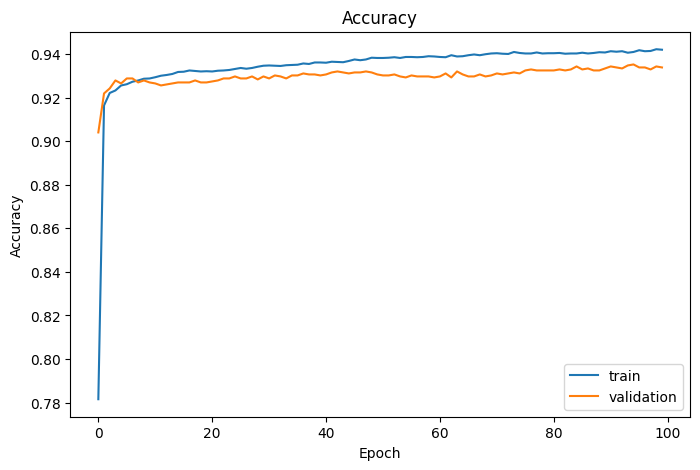

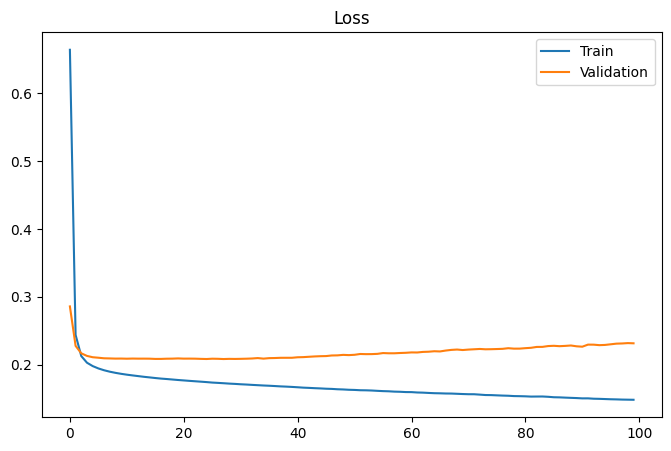

In [65]:
#Akurasi dan Grafik

plt.figure(figsize=(8,5))

#mengambil data akurasi training
plt.plot(
history.history['accuracy'],
label = 'train'
)

#mengambil data validasi akurasi
plt.plot(
history.history['val_accuracy'],
label = 'validation'
)

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(
['train','validation']
)
plt.title("Accuracy")
plt.show()

#mengambil data grafik loss
plt.figure(figsize=(8,5))

plt.plot(

    history.history["loss"],

    label="Train"

)

plt.plot(

    history.history["val_loss"],

    label="Validation"

)

plt.legend()

plt.title("Loss")

plt.show()

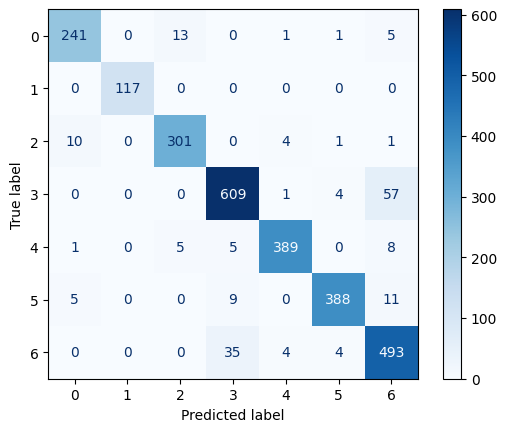

In [66]:
#Confussion matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(

    y_true,

    y_pred,

    cmap="Blues"

)

plt.show()

In [88]:
#perbandingan ANN dan KERAS
comparison_df = pd.DataFrame({

    "Model":[

        "ANN From Scratch",

        "TensorFlow Keras"

    ],

    "Accuracy":[

        round(best_ann["accuracy"],4),

        round(keras_metrics["accuracy"],4)

    ],

    "Precision":[

        round(best_ann["precision"],4),

        round(keras_metrics["precision"],4)

    ],

    "Recall":[

        round(best_ann["recall"],4),

        round(keras_metrics["recall"],4)

    ],

    "F1 Score":[

        round(best_ann["f1"],4),

        round(keras_metrics["f1"],4)

    ],

    "Training Time (detik)":[

        round(best_ann["training_time"],2),

        round(keras_training_time,2)

    ]

})

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (detik)
0,ANN From Scratch,0.9310,0.9422,0.9418,0.9419,5.81
1,TensorFlow Keras,0.9328,0.9445,0.9427,0.9435,82.31


In [89]:
# Menyimpan Hasil

import os

os.makedirs("hasil", exist_ok=True)

with pd.ExcelWriter("hasil/hasil_eksperimen.xlsx") as writer:

    weight_df.to_excel(
        writer,
        sheet_name="Weight",
        index=False
    )

    activation_df.to_excel(
        writer,
        sheet_name="Activation",
        index=False
    )

    lr_df.to_excel(
        writer,
        sheet_name="LearningRate",
        index=False
    )

    batch_df.to_excel(
        writer,
        sheet_name="BatchSize",
        index=False
    )

    epoch_df.to_excel(
        writer,
        sheet_name="Epoch",
        index=False
    )

    neuron_df.to_excel(
        writer,
        sheet_name="Neuron",
        index=False

)
    regularization_df.to_excel(
        writer,
        sheet_name="Regularization",
        index=False
    )

    comparison_df.to_excel(
        writer,
        sheet_name="Comparison",
        index=False
    )

print("Seluruh hasil eksperimen berhasil disimpan.")

Seluruh hasil eksperimen berhasil disimpan.


In [90]:
#AUTO DOWNLOAD HASIL

from google.colab import files

files.download("hasil/hasil_eksperimen.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>